# 06 — Model Evaluation (RetentionIQ)

Honest evaluation of the three pieces that drive the product: **churn**, **CLV**,
and **segmentation**. The point of this notebook is credibility: we say plainly
what the models do and do not do, so nothing blows up under questioning.

Headline going in: the churn label has a **target-leakage** issue we surface
here on purpose, and turn into the roadmap (early warning), rather than hide.

In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_score, recall_score
import xgboost as xgb

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA = ROOT / "data"

df = pd.read_parquet(DATA / "features" / "feature_table.parquet")
meta = json.load(open(DATA / "models" / "churn_metrics.json"))
WINDOW = meta.get("churn_window_days", 299)
FEATS = meta["feature_cols"]
print(f"{len(df):,} customers | churn window = {WINDOW} days")
print("feature_cols:", FEATS)

751,956 customers | churn window = 299 days
feature_cols: ['total_orders', 'total_revenue', 'avg_order_value', 'T', 'recency', 'days_since_last_order', 'frequency', 'monetary_value', 'refund_rate']


## 1. Churn — the leakage we need to be honest about

The label is defined as:

```
is_churned = days_since_last_order > WINDOW
```

That means `days_since_last_order` (and `t`, which moves with it) are a
deterministic function of the label. A feature that *is* the label, thresholded,
leaks the answer. We prove it: using `days_since_last_order` alone as a score
should separate the classes almost perfectly.

In [14]:
df["is_churned"] = (df["days_since_last_order"] > WINDOW).astype(int)
print("churn rate:", round(df["is_churned"].mean(), 3))

auc_leak = roc_auc_score(df["is_churned"], df["days_since_last_order"])
print(f"AUROC using days_since_last_order ALONE: {auc_leak:.4f}")
print("(~1.0 means the label leaks straight through this feature)")

churn rate: 0.489
AUROC using days_since_last_order ALONE: 1.0000
(~1.0 means the label leaks straight through this feature)


## 2. Reported vs honest AUROC

- **Reported**: the trained XGBoost scored on all features, including the leaky
  ones. This is the optimistic number.
- **Honest**: a simple model trained on **only the non-leaky** behavioural
  features (frequency, monetary, basket, refunds). This is the real predictive
  signal once we remove the answer-in-disguise.

Reported AUROC (with leaky feats): 0.9131
Honest AUROC  (no leaky feats): 0.7761  on ['frequency', 'monetary_value', 'avg_order_value', 'total_orders', 'total_revenue', 'refund_rate']


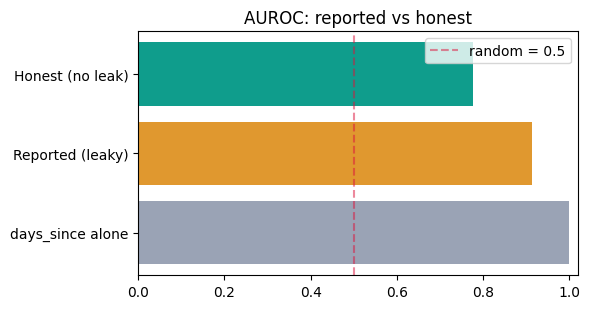

In [15]:
# reported: load the booster, score with the SAME columns (note "T" is uppercase)
booster = xgb.Booster()
booster.load_model(str(DATA / "models" / "churn_xgboost.json"))
colmap = {f: ("t" if f == "T" else f.lower()) for f in FEATS}
M = pd.DataFrame({f: df[colmap[f]] for f in FEATS})
proba = booster.predict(xgb.DMatrix(M, feature_names=FEATS))
auc_reported = roc_auc_score(df["is_churned"], proba)
print(f"Reported AUROC (with leaky feats): {auc_reported:.4f}")

# honest: drop leaky feats, cross-validate a plain logistic model
leaky = {"days_since_last_order", "T", "recency", "t"}
honest_feats = [c for c in ["frequency", "monetary_value", "avg_order_value",
                            "total_orders", "total_revenue", "refund_rate"]
                if c in df.columns and c not in leaky]
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
auc_honest = cross_val_score(clf, df[honest_feats], df["is_churned"], cv=5, scoring="roc_auc").mean()
print(f"Honest AUROC  (no leaky feats): {auc_honest:.4f}  on {honest_feats}")

plt.figure(figsize=(6, 3.2))
plt.barh(["days_since alone", "Reported (leaky)", "Honest (no leak)"],
         [auc_leak, auc_reported, auc_honest],
         color=["#9AA3B5", "#E0982F", "#0F9D8C"])
plt.axvline(0.5, color="crimson", ls="--", alpha=.5, label="random = 0.5")
plt.xlim(0, 1.02); plt.title("AUROC: reported vs honest"); plt.legend(); plt.tight_layout(); plt.show()

## 3. What the model catches at the 0.5 cut

confusion matrix [rows=actual, cols=pred]:
 [[237734 146850]
 [ 13702 353670]]
precision: 0.707
recall:    0.963


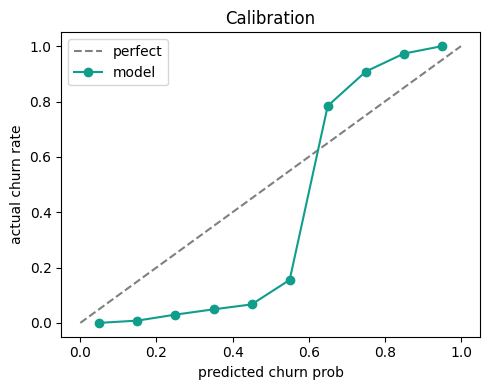

In [16]:
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(df["is_churned"], pred)
print("confusion matrix [rows=actual, cols=pred]:\n", cm)
print(f"precision: {precision_score(df['is_churned'], pred):.3f}")
print(f"recall:    {recall_score(df['is_churned'], pred):.3f}")

# calibration: predicted bucket vs actual churn rate
buckets = pd.cut(proba, np.linspace(0, 1, 11))
calib = df.assign(p=proba, b=buckets).groupby("b", observed=True)["is_churned"].mean()
mids = [iv.mid for iv in calib.index]
plt.figure(figsize=(5, 4))
plt.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
plt.plot(mids, calib.values, "o-", color="#0F9D8C", label="model")
plt.xlabel("predicted churn prob"); plt.ylabel("actual churn rate")
plt.title("Calibration"); plt.legend(); plt.tight_layout(); plt.show()

**Read:** because the label leaks through recency, the model effectively flags
customers who have **already gone quiet** rather than predicting it early. That
is why, in the scored output, the top at-risk customers tend to be low-CLV
lapsed buyers. The honest fix on the roadmap is an **early-warning** target
(predict the slowdown before the window closes), which is exactly the
"intervene early" point from the course.

## 4. CLV — sanity checks

A full BG/NBD + Gamma-Gamma holdout validation lives in `05_clv_bgnbd.ipynb`
(calibration vs holdout period). Here we sanity-check the fitted params and the
scored output: CLV should be 0 for one-time buyers (the model only speaks for
repeat buyers) and should track spend for the rest.

BG/NBD params: {'r': 0.03526398143992196, 'alpha': 6.761056378817459, 'a': 0.5015829208403754, 'b': 0.20943229020517853}
Gamma-Gamma params: {'p': 4.081664320512658, 'q': 0.43483558734109745, 'v': 3.8699695453012266}

scored customers: 751,956
share with CLV = 0 (one-time buyers): 87.8%
count    751956.00
mean          6.43
std          60.44
min           0.00
25%           0.00
50%           0.00
75%           0.00
max       20020.36
Name: predicted_clv, dtype: float64


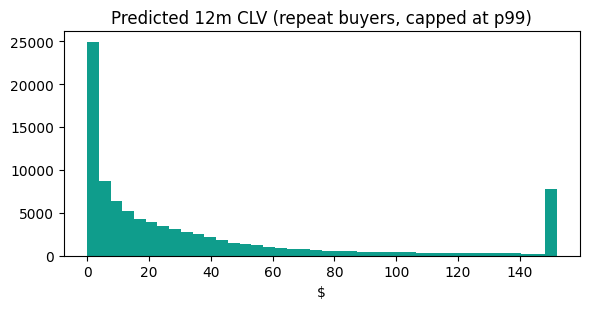

In [17]:
bg = json.load(open(DATA / "models" / "clv_bgnbd_params.json"))
gg = json.load(open(DATA / "models" / "clv_gamma_gamma_params.json"))
print("BG/NBD params:", bg)
print("Gamma-Gamma params:", gg)

scored_path = DATA / "scored" / "customer_scores.parquet"
if scored_path.exists():
    sc = pd.read_parquet(scored_path)
    zero = (sc["predicted_clv"] == 0).mean()
    print(f"\nscored customers: {len(sc):,}")
    print(f"share with CLV = 0 (one-time buyers): {zero*100:.1f}%")
    print(sc["predicted_clv"].describe().round(2))
    plt.figure(figsize=(6, 3.2))
    plt.hist(sc.loc[sc["predicted_clv"] > 0, "predicted_clv"].clip(upper=sc["predicted_clv"].quantile(.99)), bins=40, color="#0F9D8C")
    plt.title("Predicted 12m CLV (repeat buyers, capped at p99)"); plt.xlabel("$"); plt.tight_layout(); plt.show()
else:
    print("Run score_customers.py first to evaluate the scored CLV output.")

## 5. Segmentation — separation check

In [18]:
seg_path = DATA / "models" / "segmentation_kmeans.json"
if seg_path.exists():
    seg = json.load(open(seg_path))
    print(f"k = {seg['k']} | silhouette = {seg['silhouette']}")
    print("segment names:", seg["segment_names"])
    segs = pd.read_parquet(DATA / "scored" / "customer_segments.parquet")
    print("\nsegment sizes:")
    print(segs["segment"].value_counts())
else:
    print("Run 05_segmentation.ipynb first.")

k = 6 | silhouette = 0.4199
segment names: {'4': 'Power buyers', '0': 'Loyal', '5': 'Promising', '1': 'High returns', '2': 'At risk', '3': 'Hibernating'}

segment sizes:
segment
Promising       272912
Hibernating     223919
Loyal           106917
Power buyers     85715
High returns     41656
At risk          20837
Name: count, dtype: int64


## Bottom line (say this out loud in the demo)

1. **Churn**: the current model fires **late** because the label leaks through
   recency. We show it on purpose. Honest signal is modest; early warning is the
   roadmap. This matches the "intervene early" lesson.
2. **CLV**: solid for repeat buyers, 0 for one-timers by design (not a bug). The
   88% one-time base is both a modelling constraint and the market opportunity.
3. **Segmentation**: usable, actionable groupings rather than crisp natural
   classes — fine for routing actions, and it now flows into the demo per
   customer.